# **THE PROMOTION PARADOX:**
### *Fixing Biased Talent Promotion Decisions Through Data-Driven HR Analytics*

**Final project by Syntax Society**
- Bayu Maitra
- Dian Ulhaq
- Febiansyah Ahnaf
- Keisya Nisrina Aulia
- Maslahatul Husna

# **IMPORT TOOLS & LOAD DATASET**

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
pip install numpy==1.26.4

In [85]:
pip install scikit-learn-extra

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [87]:
df_scaled = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data set/dataset_clean_scaled.csv')

In [88]:
df_scaled.head()

,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Leadership_Index,Performance_Index,Potential_Index,Growth_Momentum,Leadership_Influence,Performance_Consistency
0,-0.701018,-0.220184,-1.035977,1.627892,0.349011,0.0,0.172393,0.499204,-0.805039,0.260405,-0.175344,0.357239
1,1.465699,-0.184340,-0.610027,0.178266,-1.591787,0.0,-1.443855,-1.437583,-1.281323,-0.135183,-0.363274,1.096978
2,1.465699,-1.116279,-0.077591,-0.727750,1.231192,0.0,0.420284,1.245916,0.233415,-0.280955,0.276325,0.009126
3,0.743460,0.030723,-1.497422,-0.727750,0.031426,0.0,0.043490,-0.002494,-1.296939,0.133730,-0.229885,-0.251958
4,0.743460,0.496693,-0.769758,1.084282,0.278437,0.0,0.509525,0.475869,-0.445875,0.023922,-0.244045,1.488605


## **Drop target**

In [89]:
df_scaled = df_scaled.drop(columns=['Promotion_Eligible'])

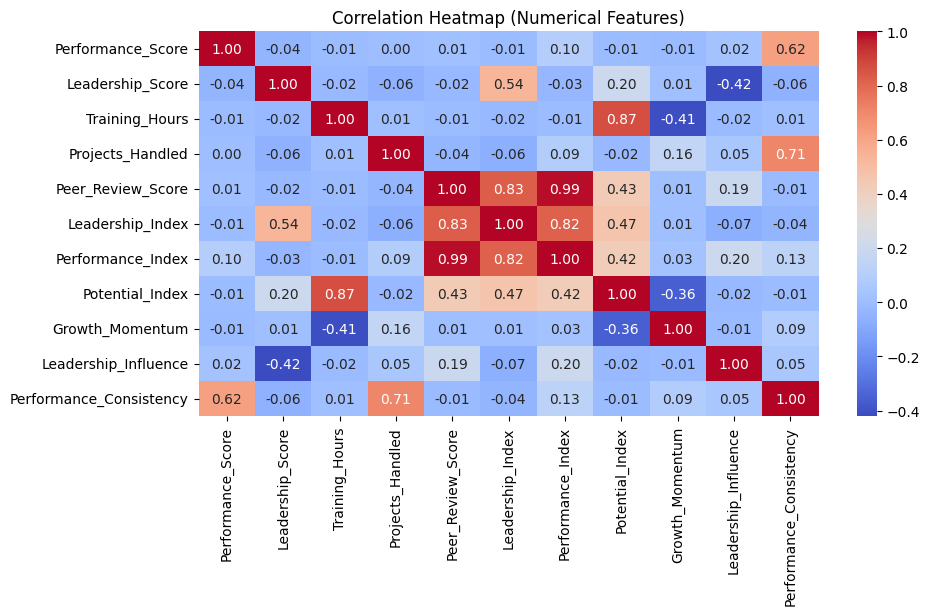

In [90]:
num_cols = df_scaled.select_dtypes(include=['number']).columns

plt.figure(figsize=(10, 5))
sns.heatmap(df_scaled[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

# **UNSUPERVISED LEARNING**

## **K-means**

###  **All features**

#### **Elbow method**

In [91]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

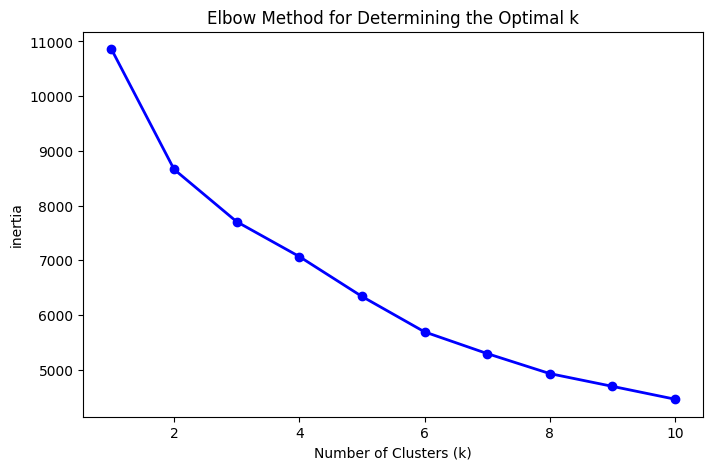

In [92]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('inertia')
plt.title('Elbow Method for Determining the Optimal k')
plt.show()


#### **silhouette_score and davies_bouldin_score**

In [93]:
X = df_scaled.values

In [94]:
results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=42).fit(X)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    inertia = kmeans.inertia_

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)

    results.append([k, sil, dbi])

df_results1 = pd.DataFrame(results, columns=['k', 'Silhouette', 'DBI'])
print(df_results1)

    k  Silhouette       DBI
0   2    0.202028  1.828185
1   3    0.187135  1.834187
2   4    0.194977  1.521013
3   5    0.197892  1.334550
4   6    0.182993  1.360843
5   7    0.170787  1.433211
6   8    0.165625  1.396923
7   9    0.167619  1.365354
8  10    0.169514  1.365004


In [95]:
best_sil_k = df_results1.loc[df_results1['Silhouette'].idxmax(), 'k']
best_dbi_k = df_results1.loc[df_results1['DBI'].idxmin(), 'k']

print("The best K according to Silhouette =", best_sil_k)
print("The best K according to DBI        =", best_dbi_k)

The best K according to Silhouette = 2
The best K according to DBI        = 5


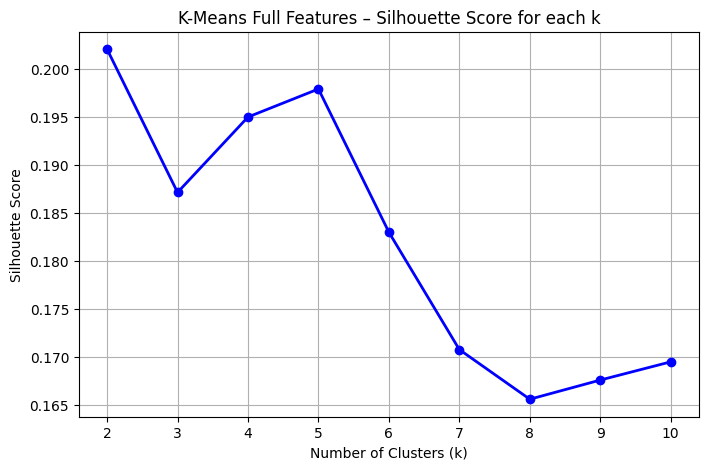

In [96]:
plt.figure(figsize=(8,5))
plt.plot(df_results1["k"], df_results1["Silhouette"], 'bo-', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Full Features – Silhouette Score for each k")
plt.grid(True)
plt.show()

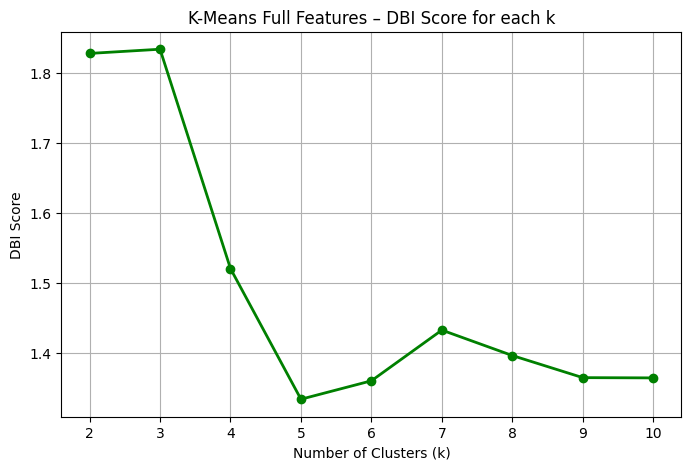

In [97]:
plt.figure(figsize=(8,5))
plt.plot(df_results1["k"], df_results1["DBI"], 'go-', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("DBI Score")
plt.title("K-Means Full Features – DBI Score for each k")
plt.grid(True)
plt.show()

#### **Visualization k = 4**

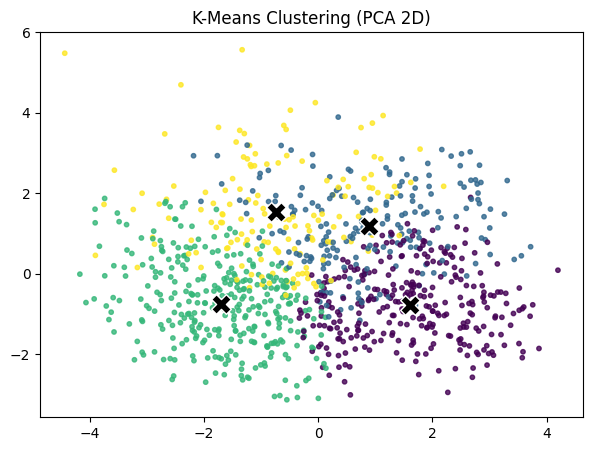

In [98]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# 1. Fit PCA to data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Transform centroids to PCA
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

# 3. Plot data + centroids
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.8)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            marker='X', s=200, c='black', edgecolor='white')
plt.title("K-Means Clustering (PCA 2D)")
plt.show()

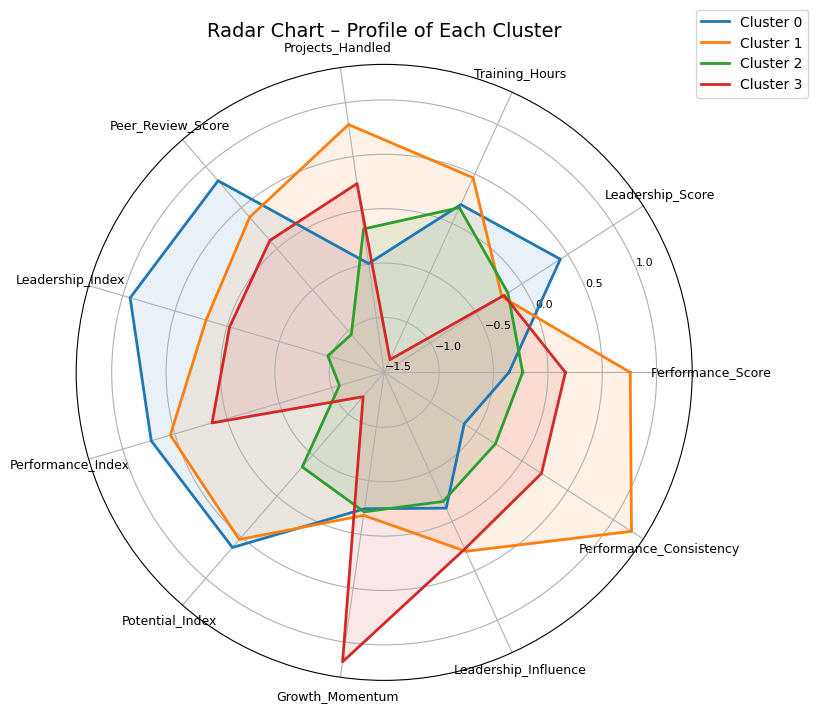

In [99]:
df_cluster = df_scaled.copy()
df_cluster['cluster'] = labels

# Calculate the average of each feature per cluster
cluster_means = df_cluster.groupby('cluster').mean()

# Radar chart
features = cluster_means.columns
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

plt.figure(figsize=(8, 8))

for idx in cluster_means.index:
    values = cluster_means.loc[idx].tolist()
    values += values[:1]  # Close the circle

    plt.polar(angles, values, linewidth=2, label=f'Cluster {idx}')
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], features, fontsize=9)
plt.yticks(fontsize=8)
plt.title('Radar Chart – Profile of Each Cluster', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

#### **Visualization k = 5**

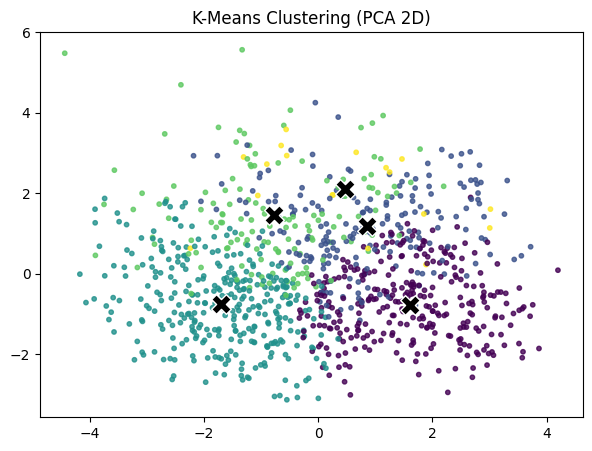

In [100]:
# X = df_scaled
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# 1. Fit PCA to data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Transform centroids to PCA
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

# 3. Plot data + centroids
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.8)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            marker='X', s=200, c='black', edgecolor='white')
plt.title("K-Means Clustering (PCA 2D)")
plt.show()

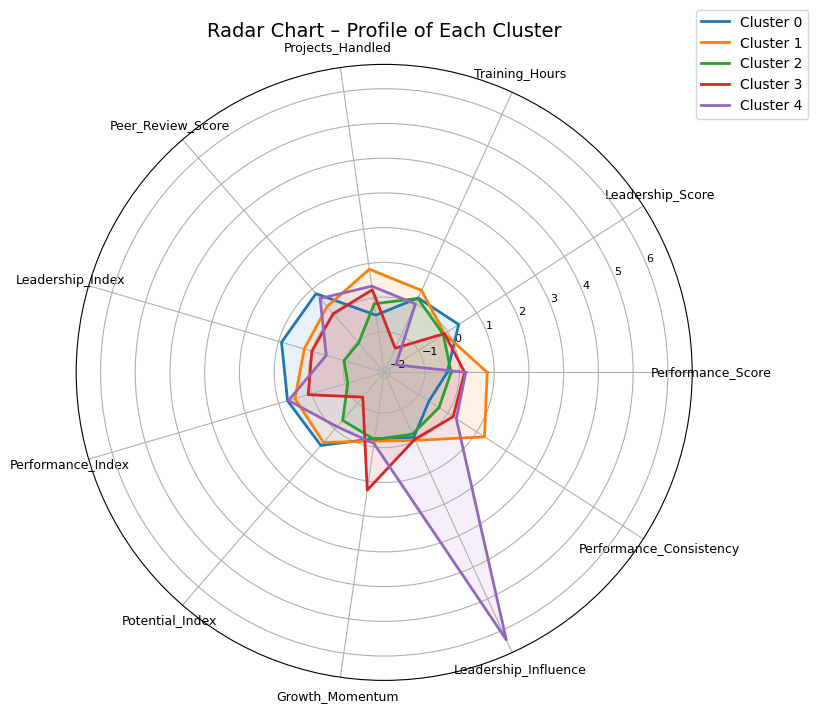

In [101]:
df_cluster = df_scaled.copy()
df_cluster['cluster'] = labels

# Calculate the average of each feature per cluster
cluster_means = df_cluster.groupby('cluster').mean()

# Radar chart
features = cluster_means.columns
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

plt.figure(figsize=(8, 8))

for idx in cluster_means.index:
    values = cluster_means.loc[idx].tolist()
    values += values[:1]  # Close the circle

    plt.polar(angles, values, linewidth=2, label=f'Cluster {idx}')
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], features, fontsize=9)
plt.yticks(fontsize=8)
plt.title('Radar Chart – Profile of Each Cluster', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

### **Selected features**

In [102]:
df_scaled2 = df_scaled.drop(columns=['Training_Hours', 'Performance_Index'])

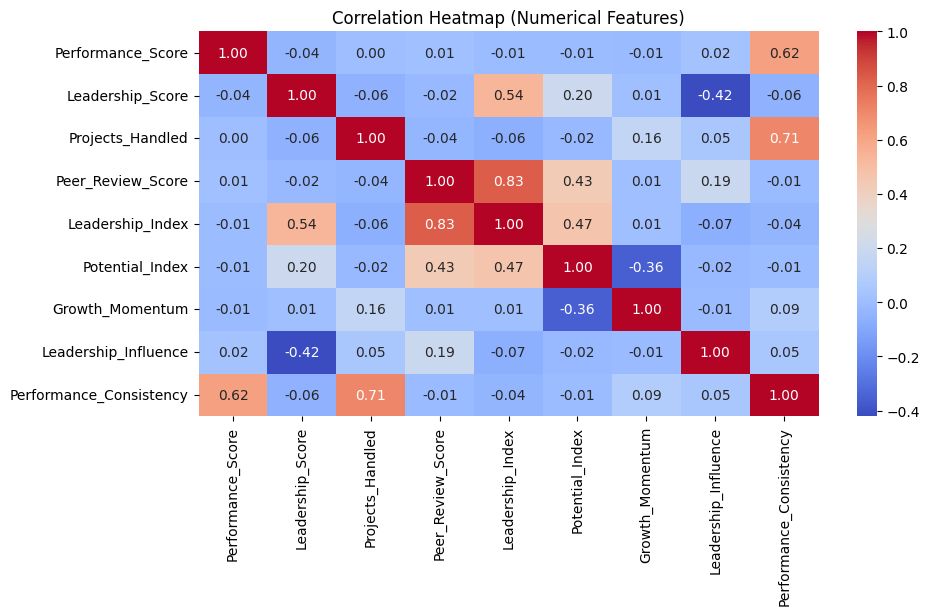

In [103]:
num_cols = df_scaled2.select_dtypes(include=['number']).columns

plt.figure(figsize=(10, 5))
sns.heatmap(df_scaled2[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

#### **Elbow method**

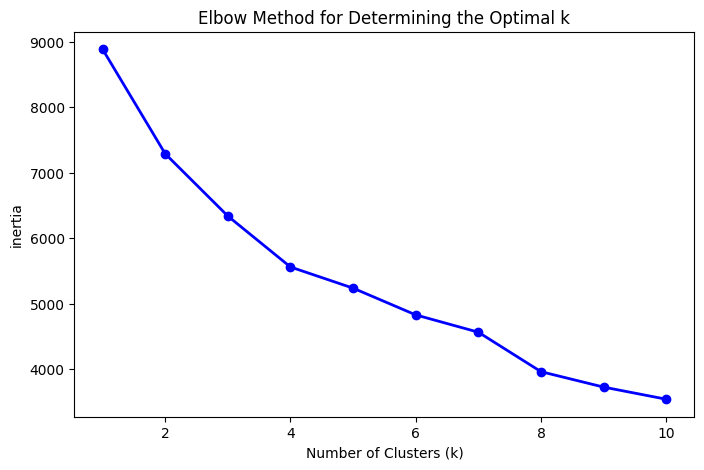

In [104]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled2)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('inertia')
plt.title('Elbow Method for Determining the Optimal k')
plt.show()

#### **Silhouette_score and davies_bouldin_score**

In [105]:
X = df_scaled2.values

In [106]:
results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=42).fit(X)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    inertia = kmeans.inertia_

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)

    results.append([k, sil, dbi])

df_results = pd.DataFrame(results, columns=['k', 'Silhouette', 'DBI'])
print(df_results)

    k  Silhouette       DBI
0   2    0.186731  1.938774
1   3    0.186009  1.709993
2   4    0.198152  1.394889
3   5    0.206692  1.233940
4   6    0.174102  1.399016
5   7    0.172635  1.424813
6   8    0.168644  1.390259
7   9    0.169144  1.365113
8  10    0.172818  1.318041


In [107]:
best_sil_k = df_results.loc[df_results['Silhouette'].idxmax(), 'k']
best_dbi_k = df_results.loc[df_results['DBI'].idxmin(), 'k']

print("Best k according to Silhouette =", best_sil_k)
print("Best k according to DBI        =", best_dbi_k)

Best k according to Silhouette = 5
Best k according to DBI        = 5


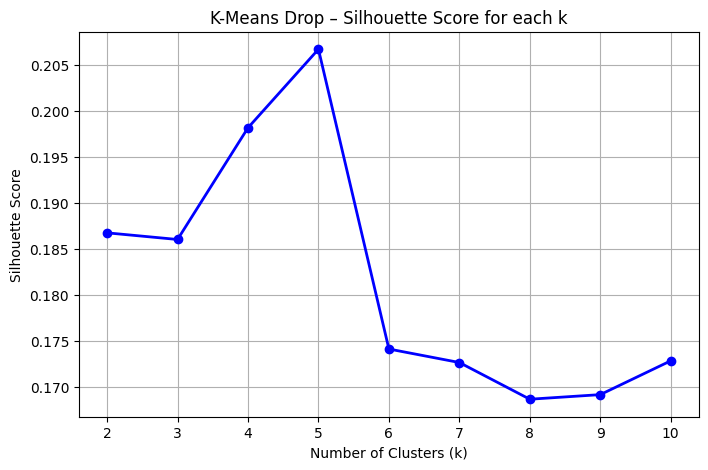

In [108]:
plt.figure(figsize=(8,5))
plt.plot(df_results["k"], df_results["Silhouette"], 'bo-', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Drop – Silhouette Score for each k")
plt.grid(True)
plt.show()

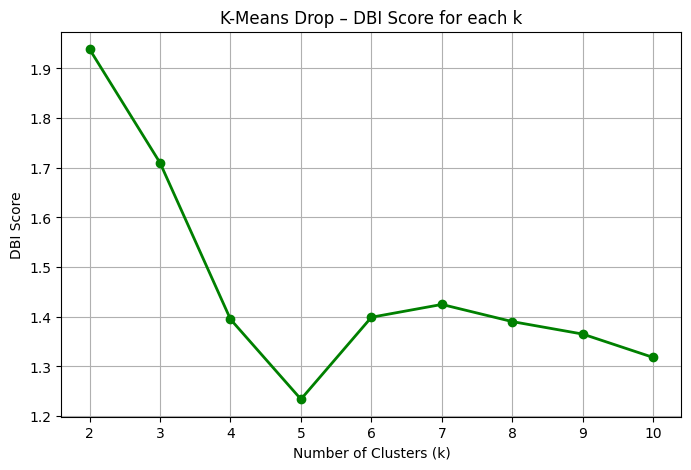

In [109]:
plt.figure(figsize=(8,5))
plt.plot(df_results["k"], df_results["DBI"], 'go-', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("DBI Score")
plt.title("K-Means Drop – DBI Score for each k")
plt.grid(True)
plt.show()

#### **Visualization k = 4**

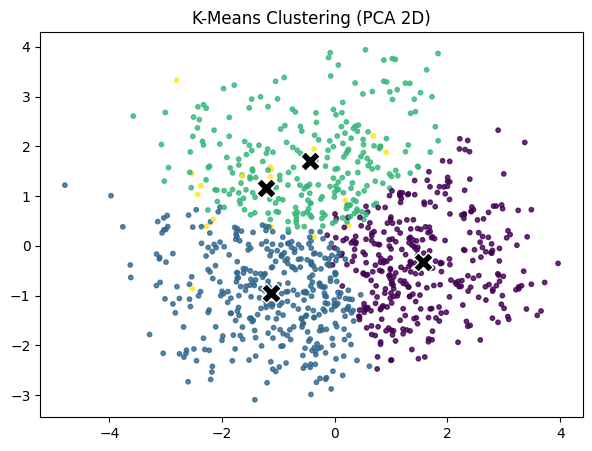

In [110]:
# X = df_scaled2
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

# 1. Fit PCA to data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Transform centroids to PCA
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

# 3. Plot data + centroids
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.8)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            marker='X', s=200, c='black', edgecolor='white')
plt.title("K-Means Clustering (PCA 2D)")
plt.show()

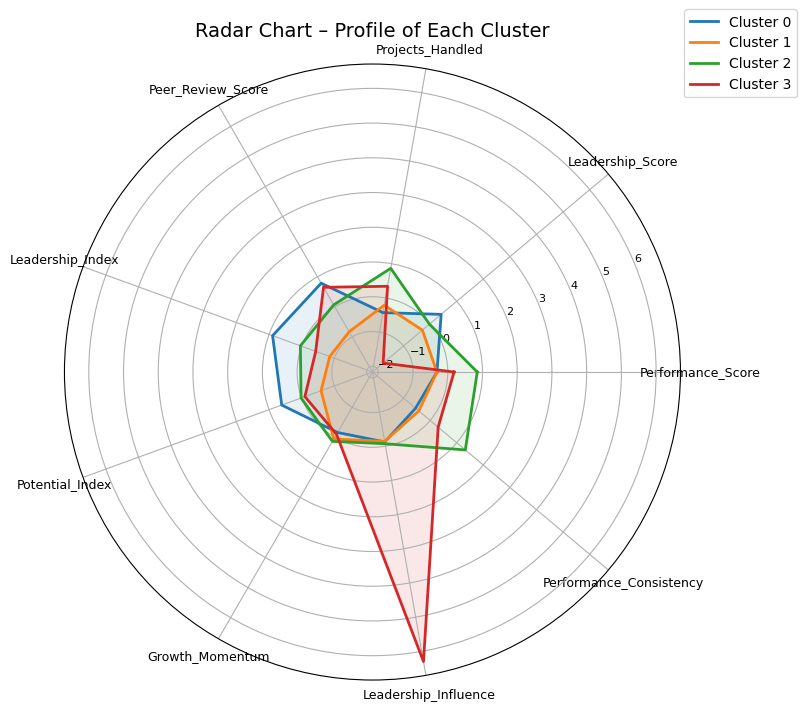

In [111]:
df_cluster = df_scaled2.copy()
df_cluster['cluster'] = labels

# Calculate the average of each feature per cluster
cluster_means = df_cluster.groupby('cluster').mean()

# Radar chart
features = cluster_means.columns
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

plt.figure(figsize=(8, 8))

for idx in cluster_means.index:
    values = cluster_means.loc[idx].tolist()
    values += values[:1]  # Close the circle

    plt.polar(angles, values, linewidth=2, label=f'Cluster {idx}')
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], features, fontsize=9)
plt.yticks(fontsize=8)
plt.title('Radar Chart – Profile of Each Cluster', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

#### **Visualization k = 5**

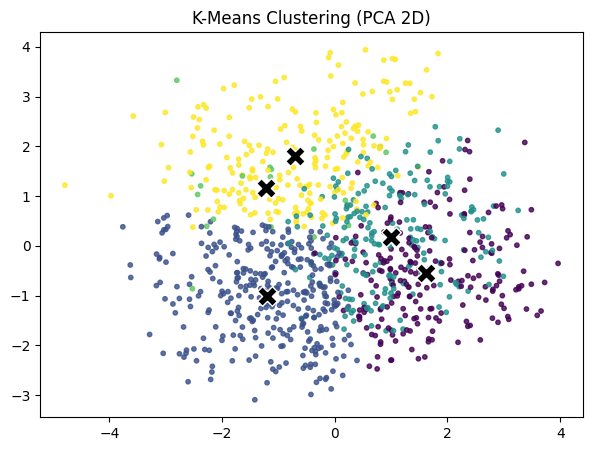

In [112]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# 1. Fit PCA to data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Transform centroids to PCA
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

# 3. Plot data + centroids
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.8)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            marker='X', s=200, c='black', edgecolor='white')
plt.title("K-Means Clustering (PCA 2D)")
plt.show()

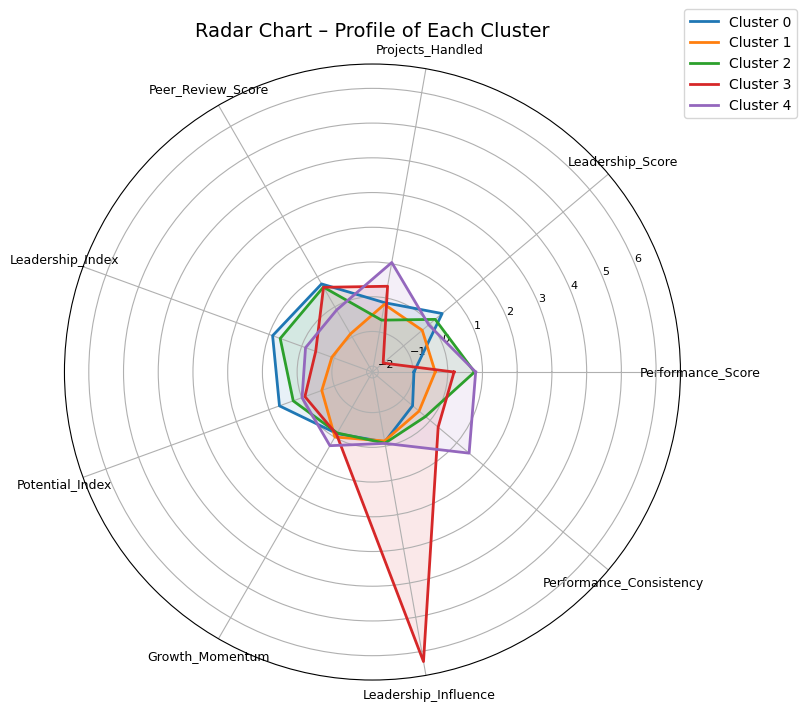

In [113]:
df_cluster = df_scaled2.copy()
df_cluster['cluster'] = labels

# Calculate the average of each feature per cluster
cluster_means = df_cluster.groupby('cluster').mean()

# Radar chart
features = cluster_means.columns
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

plt.figure(figsize=(8, 8))

for idx in cluster_means.index:
    values = cluster_means.loc[idx].tolist()
    values += values[:1]  # Close the circle

    plt.polar(angles, values, linewidth=2, label=f'Cluster {idx}')
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], features, fontsize=9)
plt.yticks(fontsize=8)
plt.title('Radar Chart – Profile of Each Cluster', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

## **Gaussian mixture model**

#### **Silhouette_score and davies_bouldin_score**

In [114]:
X_gmm = df_scaled2.values

In [115]:
results_gmm = []

for k in range(2, 11):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=10,
        random_state=42)

    # Fit data to X_gmm
    gmm.fit(X_gmm)

    # Label cluster from GMM
    labels = gmm.predict(X_gmm)

    # Calculate Silhouette and DBI based on X_gmm
    sil = silhouette_score(X_gmm, labels)
    dbi = davies_bouldin_score(X_gmm, labels)

    results_gmm.append([k, sil, dbi])

df_gmm_results = pd.DataFrame(results_gmm, columns=["k", "Silhouette", "DBI"])
print(df_gmm_results)

    k  Silhouette       DBI
0   2    0.134494  3.084769
1   3    0.109639  2.504992
2   4    0.104863  2.234721
3   5    0.060657  2.381891
4   6    0.082509  2.327006
5   7    0.057874  2.895349
6   8    0.040537  2.072294
7   9    0.029912  2.770524
8  10   -0.006207  3.378298


In [116]:
best_sil_k = df_results.loc[df_gmm_results['Silhouette'].idxmax(), 'k']
best_dbi_k = df_results.loc[df_gmm_results['DBI'].idxmin(), 'k']

print("Best k according to Silhouette =", best_sil_k)
print("Best k according to DBI        =", best_dbi_k)

Best k according to Silhouette = 2
Best k according to DBI        = 8


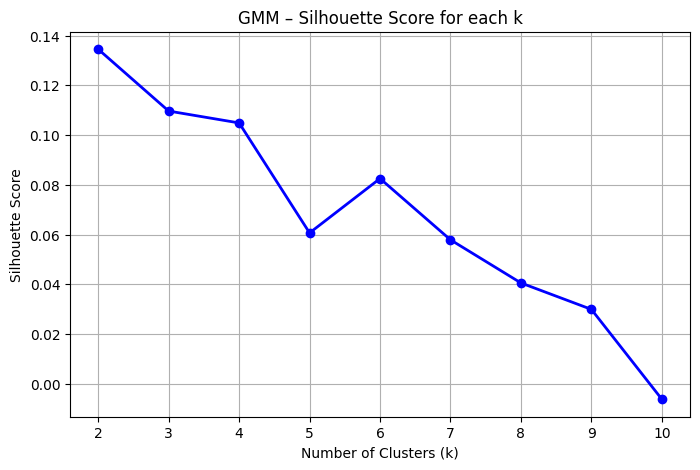

In [117]:
plt.figure(figsize=(8,5))
plt.plot(df_gmm_results["k"], df_gmm_results["Silhouette"], 'bo-', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("GMM – Silhouette Score for each k")
plt.grid(True)
plt.show()

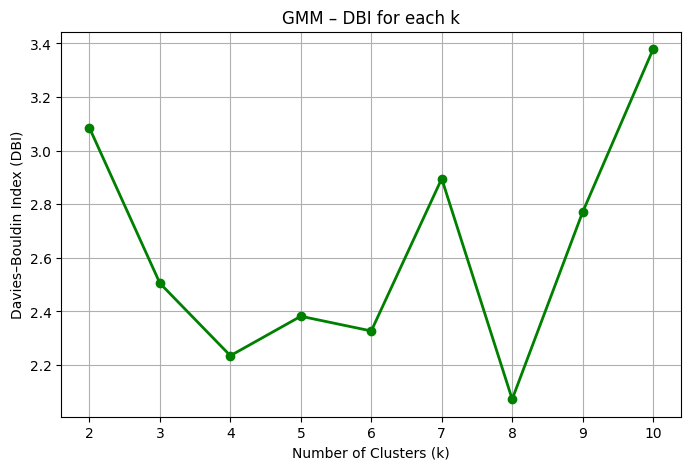

In [118]:
plt.figure(figsize=(8,5))
plt.plot(df_gmm_results["k"], df_gmm_results["DBI"], 'go-', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies–Bouldin Index (DBI)")
plt.title("GMM – DBI for each k")
plt.grid(True)
plt.show()

#### **Visualization k= 4**

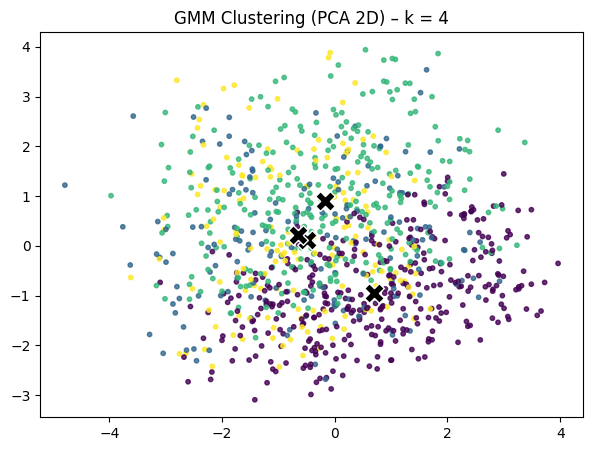

In [119]:
# Recreate the GMM model for a specific k
gmm_k = GaussianMixture(n_components=4, random_state=42)
gmm_k.fit(X_gmm)
labels = gmm_k.predict(X_gmm)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_gmm)

# Transform cluster means to PCA
means = gmm_k.means_
means_pca = pca.transform(means)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.8)
plt.scatter(means_pca[:,0], means_pca[:,1],
            marker='X', s=200, c='black', edgecolor='white')
plt.title(f"GMM Clustering (PCA 2D) – k = {4}")
plt.show()

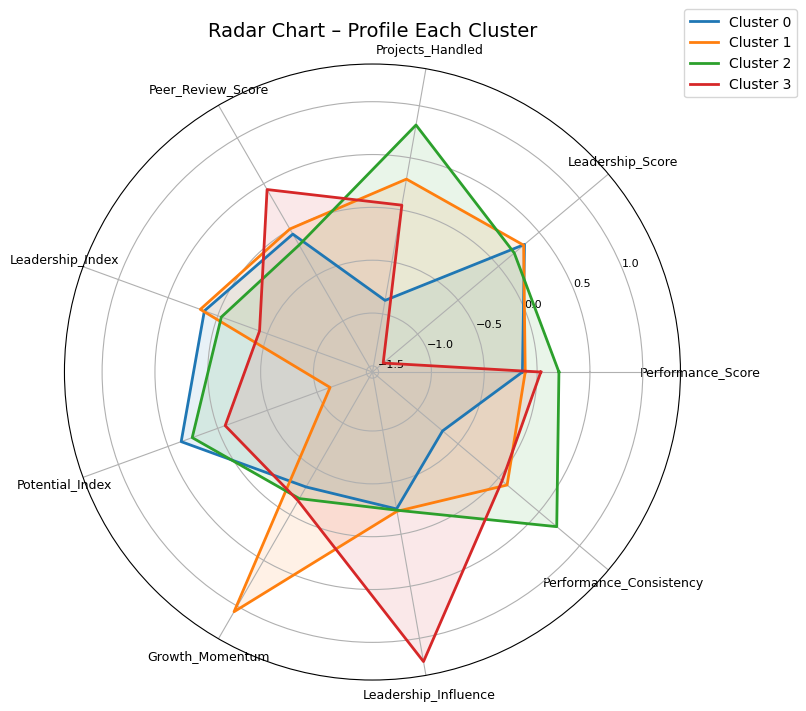

In [120]:
df_cluster = df_scaled2.copy()
df_cluster['cluster'] = labels

# Calculate the average of each feature for each cluster
cluster_means = df_cluster.groupby('cluster').mean()

# Radar chart
features = cluster_means.columns
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

plt.figure(figsize=(8, 8))

for idx in cluster_means.index:
    values = cluster_means.loc[idx].tolist()
    values += values[:1]  # Close the circle

    plt.polar(angles, values, linewidth=2, label=f'Cluster {idx}')
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], features, fontsize=9)
plt.yticks(fontsize=8)
plt.title('Radar Chart – Profile Each Cluster', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

#### **Visualization k = 5**

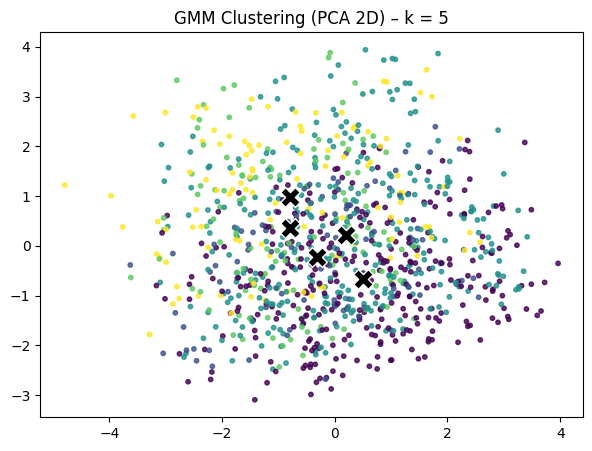

In [121]:
# Recreate the GMM model for a specific k
gmm_k = GaussianMixture(n_components=5, random_state=42)
gmm_k.fit(X_gmm)
labels = gmm_k.predict(X_gmm)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_gmm)

# Transform cluster means to PCA
means = gmm_k.means_
means_pca = pca.transform(means)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.8)
plt.scatter(means_pca[:,0], means_pca[:,1],
            marker='X', s=200, c='black', edgecolor='white')
plt.title(f"GMM Clustering (PCA 2D) – k = {5}")
plt.show()

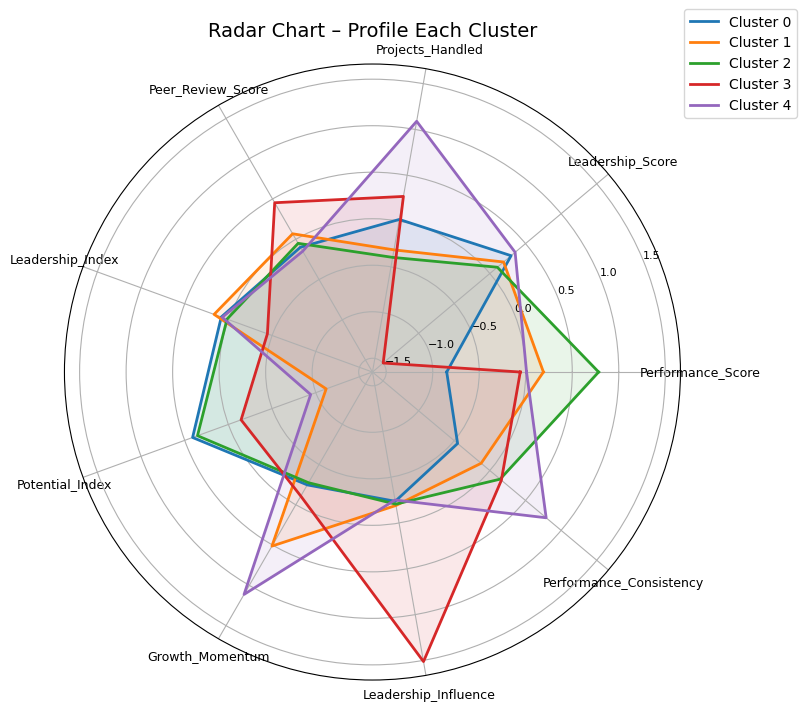

In [122]:
df_cluster = df_scaled2.copy()
df_cluster['cluster'] = labels

# Calculate the average of each feature for each cluster
cluster_means = df_cluster.groupby('cluster').mean()

# Radar chart
features = cluster_means.columns
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

plt.figure(figsize=(8, 8))

for idx in cluster_means.index:
    values = cluster_means.loc[idx].tolist()
    values += values[:1]  # Close the circle

    plt.polar(angles, values, linewidth=2, label=f'Cluster {idx}')
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], features, fontsize=9)
plt.yticks(fontsize=8)
plt.title('Radar Chart – Profile Each Cluster', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

## **K-medoids**

#### **Silhouette_score and davies_bouldin_score**

In [133]:
X_km = df_scaled2.values

In [134]:
results_kmedoids = []

for k in range(2, 11):

    # K-Medoids (using ‘pam’ as the default method)
    kmed = KMedoids(
        n_clusters=k,
        metric='euclidean',
        init='k-medoids++',
        random_state=42
    )

    # Fit to data X_gmm
    labels = kmed.fit_predict(X_gmm)

    # Calculate the Silhouette & DBI
    sil = silhouette_score(X_gmm, labels)
    dbi = davies_bouldin_score(X_gmm, labels)

    results_kmedoids.append([k, sil, dbi])

df_kmedoids_results = pd.DataFrame(results_kmedoids, columns=["k", "Silhouette", "DBI"])
print(df_kmedoids_results)

    k  Silhouette       DBI
0   2    0.185657  1.940237
1   3    0.126268  2.159141
2   4    0.133357  1.749580
3   5    0.138719  1.811541
4   6    0.134317  1.715122
5   7    0.134963  1.667757
6   8    0.122716  1.748814
7   9    0.123743  1.675883
8  10    0.124854  1.563598


In [135]:
best_sil_k = df_results.loc[df_kmedoids_results['Silhouette'].idxmax(), 'k']
best_dbi_k = df_results.loc[df_kmedoids_results['DBI'].idxmin(), 'k']

print("Best k according to Silhouette =", best_sil_k)
print("Best k according to DBI        =", best_dbi_k)

Best k according to Silhouette = 2
Best k according to DBI        = 10


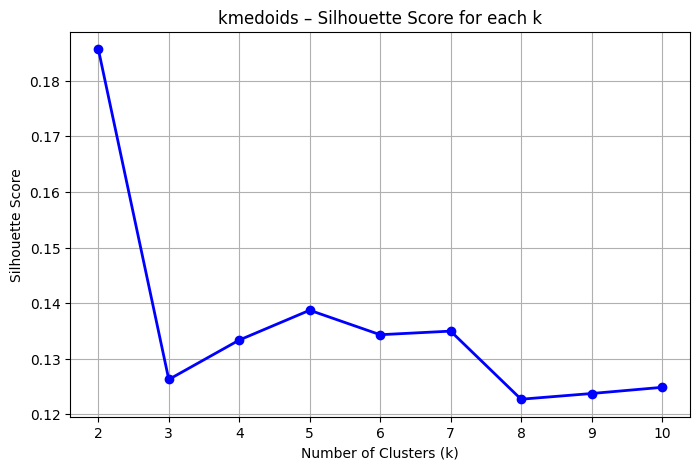

In [136]:
plt.figure(figsize=(8,5))
plt.plot(df_kmedoids_results["k"], df_kmedoids_results["Silhouette"], 'bo-', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("kmedoids – Silhouette Score for each k")
plt.grid(True)
plt.show()

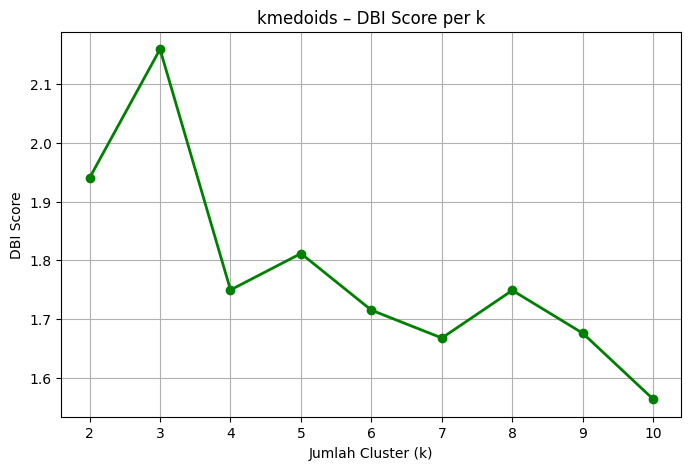

In [127]:
plt.figure(figsize=(8,5))
plt.plot(df_kmedoids_results["k"], df_kmedoids_results["DBI"], 'go-', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("DBI Score")
plt.title("kmedoids – DBI Score for each k")
plt.grid(True)
plt.show()

#### **Visualization k = 4**

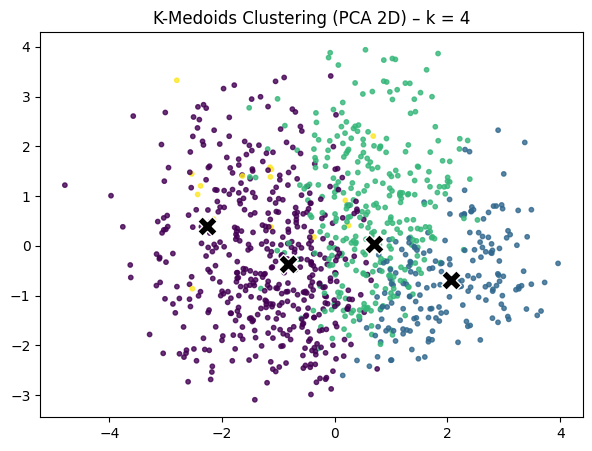

In [139]:
kmed = KMedoids(n_clusters=4,
    metric='euclidean',
    init='k-medoids++',
    random_state=42
)
labels = kmed.fit_predict(X_gmm)

# Medoid is the representation of the “centroid” of K-Medoids
medoids = kmed.cluster_centers_

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_gmm)

# Transform medoids to PCA
medoids_pca = pca.transform(medoids)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.8)
plt.scatter(medoids_pca[:,0], medoids_pca[:,1],
            marker='X', s=200, c='black', edgecolor='white')

plt.title(f"K-Medoids Clustering (PCA 2D) – k = {4}")
plt.show()

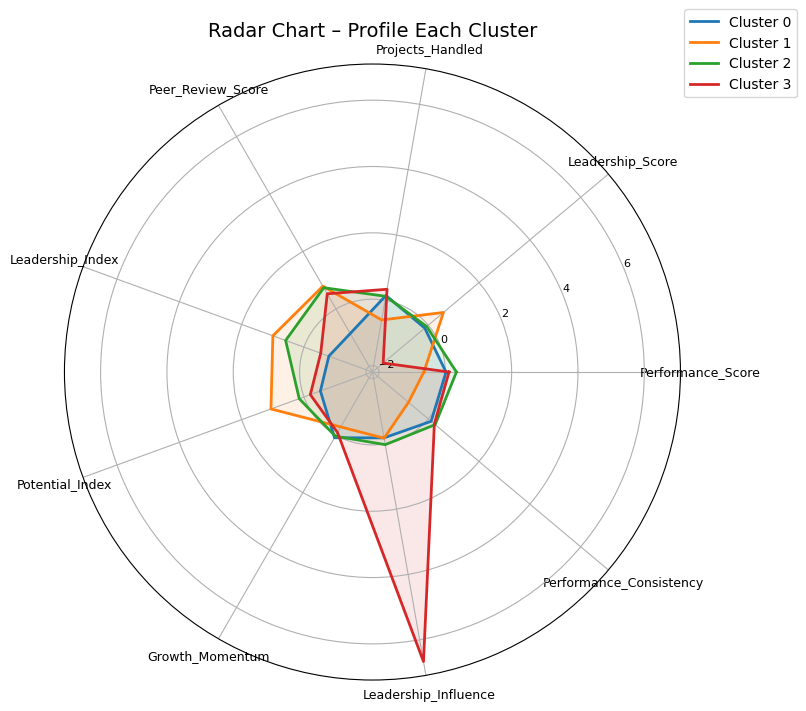

In [140]:
df_cluster = df_scaled2.copy()
df_cluster['cluster'] = labels

# Calculate the average of each feature for each cluster
cluster_means = df_cluster.groupby('cluster').mean()

# Radar chart
features = cluster_means.columns
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

plt.figure(figsize=(8, 8))

for idx in cluster_means.index:
    values = cluster_means.loc[idx].tolist()
    values += values[:1]  # Close the circle

    plt.polar(angles, values, linewidth=2, label=f'Cluster {idx}')
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], features, fontsize=9)
plt.yticks(fontsize=8)
plt.title('Radar Chart – Profile Each Cluster', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

#### **Visualization k = 5**

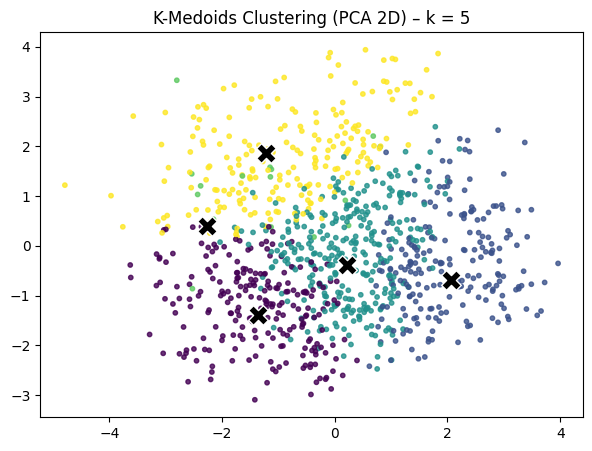

In [141]:
kmed = KMedoids(n_clusters=5,
    metric='euclidean',
    init='k-medoids++',
    random_state=42
)
labels = kmed.fit_predict(X_gmm)

# Medoid is the representation of the “centroid” of K-Medoids
medoids = kmed.cluster_centers_

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_gmm)

# Transform medoids to PCA
medoids_pca = pca.transform(medoids)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.8)
plt.scatter(medoids_pca[:,0], medoids_pca[:,1],
            marker='X', s=200, c='black', edgecolor='white')

plt.title(f"K-Medoids Clustering (PCA 2D) – k = {5}")
plt.show()

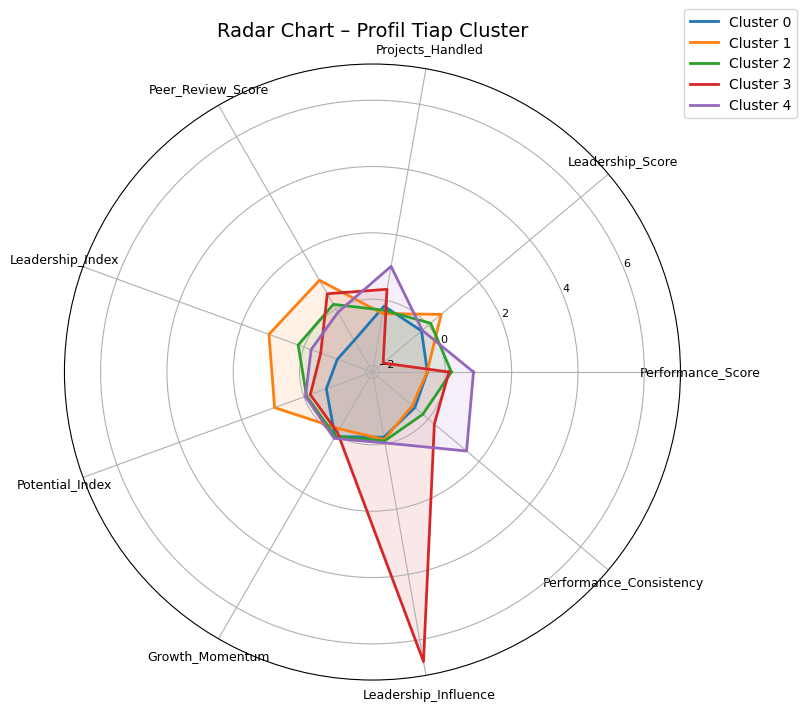

In [142]:
df_cluster = df_scaled2.copy()
df_cluster['cluster'] = labels

# Calculate the average of each feature for each cluster
cluster_means = df_cluster.groupby('cluster').mean()

# Radar chart
features = cluster_means.columns
num_features = len(features)

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

plt.figure(figsize=(8, 8))

for idx in cluster_means.index:
    values = cluster_means.loc[idx].tolist()
    values += values[:1]  # Close the circle

    plt.polar(angles, values, linewidth=2, label=f'Cluster {idx}')
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], features, fontsize=9)
plt.yticks(fontsize=8)
plt.title('Radar Chart – Profil Tiap Cluster', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

# **MODEL EVALUATION AND CONCLUTION**

**Model Evaluation**
- K-Means: Achieved the highest overall Silhouette Score across K values. Produced consistently lower DBI scores, indicating better-defined and more compact clusters. At K = 5, K-Means showed the strongest balance between cluster separation and cohesion, leading to stable and meaningful cluster structures.
- Gaussian Mixture Model (GMM): Demonstrated lower Silhouette Scores than K-Means across nearly all K values. DBI scores were significantly higher, suggesting loose, less distinct clusters. Cluster boundaries tended to overlap more due to the probabilistic nature of GMM, reducing interpretability.
- K-Medoids: Performed better than GMM but still slightly weaker than K-Means. Silhouette Scores were moderate but did not surpass K-Means for any K. DBI values were acceptable but consistently higher than K-Means, indicating less compact clusters.

**Conclusion**\
Across all tested algorithms, K-Means with K = 5 delivered the most coherent, interpretable, and well-separated clusters. This makes it the most suitable unsupervised method for segmenting employee performance profiles in this dataset.

# **CLUSTERING AND INTERPRETATION**

In [151]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

In [152]:
df_kmeans = df_scaled2.copy()
df_kmeans['Cluster'] = labels

cluster_profile = df_kmeans.groupby('Cluster').mean()
cluster_profile

,Performance_Score,Leadership_Score,Projects_Handled,Peer_Review_Score,Leadership_Index,Potential_Index,Growth_Momentum,Leadership_Influence,Performance_Consistency
Cluster,,,,,,,,,
0,-0.973073,0.451044,-0.141074,0.761065,0.891121,0.680988,-0.121233,-0.124077,-0.659586
1,-0.359838,-0.297149,-0.189699,-0.901413,-0.924288,-0.616356,-0.006952,-0.153121,-0.417072
2,0.771508,0.190803,-0.651223,0.655633,0.658259,0.259265,-0.141002,-0.088472,-0.174647
3,0.181718,-1.765451,0.339335,0.648953,-0.429706,-0.098856,-0.099120,6.298015,0.301637
4,0.804209,-0.052521,1.034324,-0.105601,-0.118079,-0.011951,0.280991,-0.082020,1.465425


In [154]:
cluster_counts = df_kmeans['Cluster'].value_counts().sort_index()
print(cluster_counts)

Cluster
0    223
1    326
2    206
3     18
4    214
Name: count, dtype: int64


In [155]:
label_map = {
    0: "Emerging Performers",
    1: "Leadership-Oriented",
    2: "Low Consistent Performers",
    3: "Reliable Core Talent",
    4: "Strategic High Performers"
}

df_kmeans['Characteristics'] = df_kmeans['Cluster'].map(label_map)
df_kmeans.head()

,Performance_Score,Leadership_Score,Projects_Handled,Peer_Review_Score,Leadership_Index,Potential_Index,Growth_Momentum,Leadership_Influence,Performance_Consistency,Cluster,Characteristics
0,-0.701018,-0.220184,1.627892,0.349011,0.172393,-0.805039,0.260405,-0.175344,0.357239,4,Strategic High Performers
1,1.465699,-0.184340,0.178266,-1.591787,-1.443855,-1.281323,-0.135183,-0.363274,1.096978,1,Leadership-Oriented
2,1.465699,-1.116279,-0.727750,1.231192,0.420284,0.233415,-0.280955,0.276325,0.009126,2,Low Consistent Performers
3,0.743460,0.030723,-0.727750,0.031426,0.043490,-1.296939,0.133730,-0.229885,-0.251958,2,Low Consistent Performers
4,0.743460,0.496693,1.084282,0.278437,0.509525,-0.445875,0.023922,-0.244045,1.488605,4,Strategic High Performers


Interpretation
- Cluster 0 → 'Emerging Performers': Strong technical capability but still require leadership development.
- Cluster 1 → 'Leadership-Oriented': Employees with good leadership presence but needing improvement in execution skills.
- Cluster 2 → 'Low Consistent Performers': Require coaching, targeted training, or potential role reassessment.
- Cluster 3 → 'Reliable Core Talent': Reliable, consistent performers who maintain day-to-day output.
- Cluster 4 → 'Strategic High Performers': Unique high-performing individuals with specialty strengths; ideal for strategic roles.

# MODEL SELECTION SUMMARY

Across all modeling experiments, tree-based models, linear models, and unsupervised clustering, the dataset showed patterns that were more continuous than sharply separable. As a result, most supervised models struggled to produce reliable predictions, even after tuning.\
\
Based on all experiment, the most suitable model for this project is K-Means with K = 5. The reasons are:
1. It produced the most stable, most compact, and most interpretable cluster structure.
2. The resulting 5 clusters align naturally with HR personas, such as emerging high performers, leadership-strong profiles, consistent low performers, stable operators, and specialized high-outliers.
3. Metrics showed K-Means was more reliable than K-Medoids and significantly better than GMM.
4. Unlike supervised models, which all struggled due to weak promotion-eligibility signals, clustering captured continuous performance patterns more effectively.

# PRACTICAL VALUE FOR HR

The five clusters uncovered through K-Means don’t just describe statistical groupings, they map directly onto real talent personas inside the organization. Each segment helps HR see the workforce with new clarity. Instead of relying on intuition or fragmented data, HR can finally understand who needs what and why.\
\
With these clusters, HR can:
- Plan succession pipelines more confidently: Emerging high performers and leadership-ready profiles can be identified early, allowing HR to prepare them for future roles instead of waiting for annual reviews or manager referrals.
- Design targeted development programs: Instead of one-size-fits-all training, HR can tailor interventions: coaching for consistent low performers, leadership development for Cluster 0 and 1, or strategic project placement for high-outlier talent.
- Make more informed placement and staffing decisions: Teams can be balanced more intentionally by distributing strengths and mitigating weaknesses based on cluster characteristics.
- Spot high-potential and at-risk employees before issues surface: Clusters reveal patterns that often remain hidden: who is quietly excelling, who is stagnating, and who may require closer support, all without relying solely on subjective manager evaluations.

In [156]:
from google.colab import files
df_kmeans.to_csv('dataset_clustered.csv', index=False)
files.download('dataset_clustered.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>